# Proyecto Sprint 12 — Recuperación de oro

**Modelos evaluados:** Linear Regression, DecisionTreeRegressor, RandomForestRegressor  

**Métrica:** sMAPE y **sMAPE_final** = 0.25·sMAPE(rougher) + 0.75·sMAPE(final)  

**Validación:** TimeSeriesSplit (validación temporal)  

**Datasets:** `gold_recovery_train.csv`, `gold_recovery_test.csv`, `gold_recovery_full.csv`

> Este notebook sigue la estructura del Sprint 12: preparación → verificación fórmula → EDA → preprocesamiento → modelos (los 3 mencionados previamente) → CV temporal → mejor modelo → predicción en test → resumen.


In [1]:
# === Librerías ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone

from sklearn.pipeline import Pipeline


from scipy.stats import ks_2samp


## 1. Carga de datos

In [2]:
# Rutas
TRAIN_PATH = "/datasets/gold_recovery_train.csv"
TEST_PATH  = "/datasets/gold_recovery_test.csv"
FULL_PATH = "/datasets/gold_recovery_full.csv"

# Carga con índice temporal 'date'
df_train = pd.read_csv(TRAIN_PATH, parse_dates=['date'], index_col='date')
df_test  = pd.read_csv(TEST_PATH,  parse_dates=['date'], index_col='date')
df_full  = pd.read_csv(FULL_PATH,  parse_dates=['date'], index_col='date')


print("Train shape:", df_train.shape)
print("Test  shape:", df_test.shape)
print("Full  path :", df_full.shape)
display(df_train.head())
display(df_test.head())
display(df_full.head())

Train shape: (16860, 86)
Test  shape: (5856, 52)
Full  path : (22716, 86)


,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
date,,,,,,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,127.092003,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,125.629232,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,123.819808,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,122.270188,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,117.988169,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,primary_cleaner.state.floatbank8_c_level,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
date,,,,,,,,,,,,,,,,,,,,,
2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,-500.704369,...,12.023554,-497.795834,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414
2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,-499.240168,...,12.058140,-498.695773,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438
2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,-502.151509,...,11.962366,-498.767484,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559
2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,-498.863574,1397.440120,-499.211024,1400.129303,-498.355873,...,12.033091,-498.350935,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987
2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,-500.808305,1398.128818,-499.504543,1402.172226,-500.810606,...,12.025367,-500.786497,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333


,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,primary_cleaner.input.sulfate,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
date,,,,,,,,,,,,,,,,,,,,,
2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,127.092003,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,125.629232,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,123.819808,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,122.270188,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,117.988169,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


## 2. Verificación — fórmula `rougher.output.recovery`

In [3]:
# Fórmula: Rec = C*(F-T) / (F*(C-T)) * 100
def recovery_formula(C, F, T):
    with np.errstate(divide='ignore', invalid='ignore'):
        return (C * (F - T)) / (F * (C - T)) * 100.0

assert {'rougher.output.concentrate_au','rougher.input.feed_au','rougher.output.tail_au','rougher.output.recovery'}.issubset(df_train.columns)

C = df_train['rougher.output.concentrate_au']
F = df_train['rougher.input.feed_au']
T = df_train['rougher.output.tail_au']

calc_rec = recovery_formula(C, F, T)
mae_check = (calc_rec - df_train['rougher.output.recovery']).abs().dropna().mean()
print("MAE verificación fórmula (rougher):", mae_check)

MAE verificación fórmula (rougher): 9.303415616264301e-15


## 3. Auditoría — columnas ausentes en `test`

In [4]:
train_cols = set(df_train.columns)
test_cols  = set(df_test.columns)
missing_in_test = sorted(list(train_cols - test_cols))

def parameter_type(col):
    parts = col.split('.')
    return parts[1] if len(parts) > 1 else None

missing_summary = pd.DataFrame({
    "columna": missing_in_test,
    "parameter_type": [parameter_type(c) for c in missing_in_test]
}).sort_values(["parameter_type","columna"])

display(missing_summary.head(20))
display(missing_summary['parameter_type'].value_counts())

# Definimos targets e intersección de features
TARGETS = ['rougher.output.recovery', 'final.output.recovery']
COMMON_COLS = sorted(list((train_cols & test_cols) - set(TARGETS)))

X_train_raw = df_train[COMMON_COLS].copy()
y_train_raw = df_train[TARGETS].copy()
X_test_raw  = df_test[COMMON_COLS].copy()

print("Nº features comunes:", len(COMMON_COLS))

,columna,parameter_type
17,rougher.calculation.au_pb_ratio,calculation
18,rougher.calculation.floatbank10_sulfate_to_au_...,calculation
19,rougher.calculation.floatbank11_sulfate_to_au_...,calculation
20,rougher.calculation.sulfate_to_au_concentrate,calculation
0,final.output.concentrate_ag,output
1,final.output.concentrate_au,output
2,final.output.concentrate_pb,output
3,final.output.concentrate_sol,output
4,final.output.recovery,output
5,final.output.tail_ag,output


output         30
calculation     4
Name: parameter_type, dtype: int64

Nº features comunes: 52


## 4. EDA — Concentraciones de Au/Ag/Pb por etapa

,au,ag,pb
stage,,,
rougher.input,7.884832,8.302613,3.432054
rougher.output,10.905884,8.772378,4.081800
primary_cleaner.output,17.936410,11.933049,6.537569
secondary_cleaner.output,3.956171,15.222165,5.074145
final.output,23.783615,7.219049,6.283760


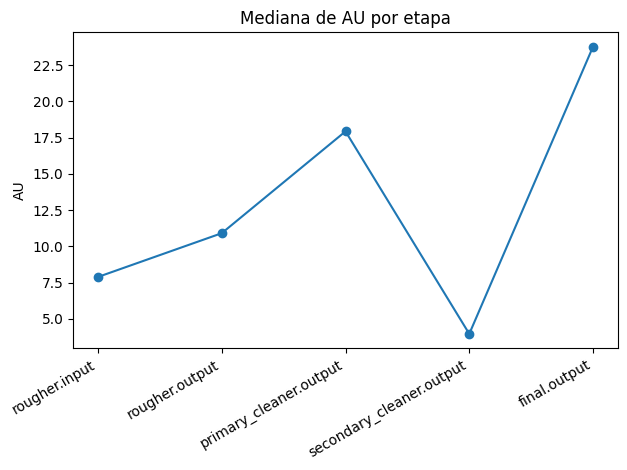

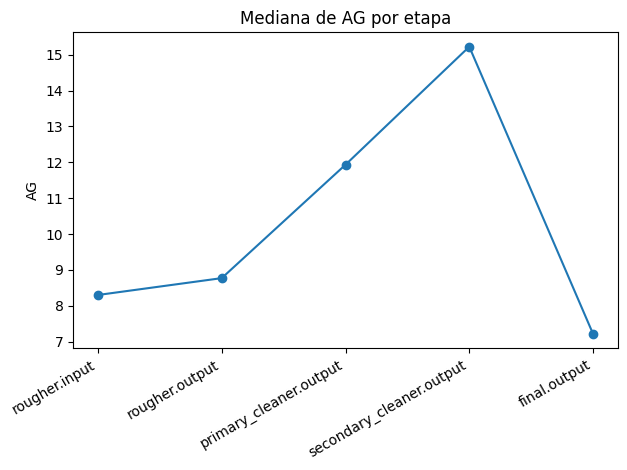

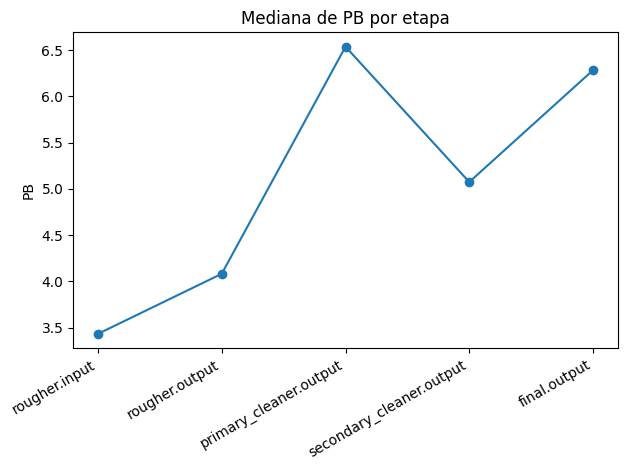

In [5]:
stages = ['rougher.input','rougher.output','primary_cleaner.output','secondary_cleaner.output','final.output']
metals = ['au','ag','pb']

def median_by_stage(df_full, stage_prefix, metal):
    cols = [c for c in df_full.columns if c.startswith(stage_prefix) and c.endswith('_'+metal)]
    if not cols: return np.nan
    return df_full[cols].median().median()

if df_full is not None:
    rows = []
    for st in stages:
        rec = {'stage': st}
        for m in metals:
            rec[m] = median_by_stage(df_full, st, m)
        rows.append(rec)
    conc_table = pd.DataFrame(rows).set_index('stage')
    display(conc_table)

    # Un plot por metal (regla: una figura por gráfico, sin colores fijos)
    for m in metals:
        plt.figure()
        vals = [median_by_stage(df_full, st, m) for st in stages]
        plt.plot(stages, vals, marker='o')
        plt.title(f"Mediana de {m.upper()} por etapa")
        plt.xticks(rotation=30, ha='right'); plt.ylabel(m.upper())
        plt.tight_layout(); plt.show()

**Interpretación**

Estas curvas reflejan el comportamiento típico del circuito: el material se enriquece en metales valiosos a medida que avanza por las etapas y se depuran impurezas en los cleaners.

**AU (oro)**

**Tendencia global:** crecimiento desde `rougher.input` → `rougher.output` → `primary_cleaner.output`, con máximo en `final.output`.

Caída en `secondary_cleaner.output`: descenso local marcado antes de volver a subir en el concentrado final. Esto es consistente con dos escenarios comunes: (A) el punto de muestreo del secondary cleaner capta un flujo intermedio/colas que arrastra menos Au, o (B) una dilución operativa temporal en esa etapa.

Lectura operativa: el proceso sí enriquece Au a lo largo del circuito y el producto final concentra el mayor contenido de oro, que es el objetivo.

**AG (plata)**

**Tendencia:** leve aumento desde `rougher.input` hasta `secondary_cleaner.output`, seguido de caída pronunciada en final.output.

**Lectura operativa:** la plata co-flota con Au en etapas iniciales, pero se depura en la limpieza final. Esto sugiere que el esquema de cleaners está priorizando la calidad del concentrado final (menos Ag como impureza), lo cual es deseable si hay penalizaciones por plata.

**PB (plomo)**

**Tendencia:** incremento desde `rougher.input` hasta un pico en `secondary_cleaner.output`, luego descenso parcial y un nivel aún relativamente alto en `final.output` (superior al feed).

**Lectura operativa:** parte del Pb acompaña al Au en los intermedios; la limpieza final reduce Pb, pero no lo elimina por completo. Si el contrato penaliza Pb, conviene revisar dosificaciones/tiempos de residencia o etapas de depuración adicionales.

**Conclusión:**

El patrón es físicamente razonable: Au se enriquece hacia el final; Ag y Pb tienden a reducirse en el concentrado final (Ag claramente; Pb parcialmente).

El descenso local en `secondary_cleaner.output` para Au no invalida el resultado: indica condiciones/muestreo propios de esa etapa.

## 5. EDA — Distribuciones `feed_size` (train vs test) + KS test

Columnas feed_size encontradas: 2


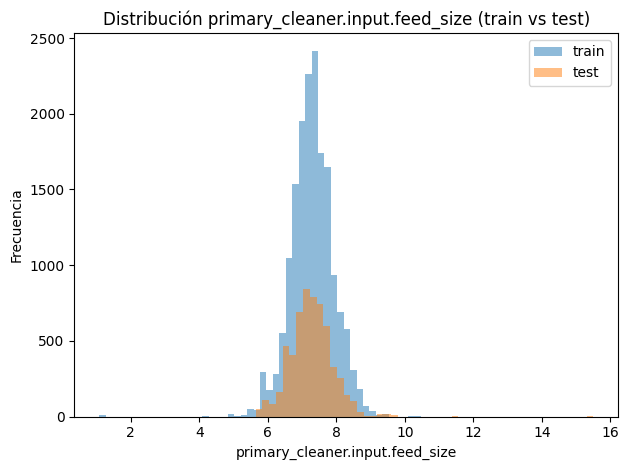

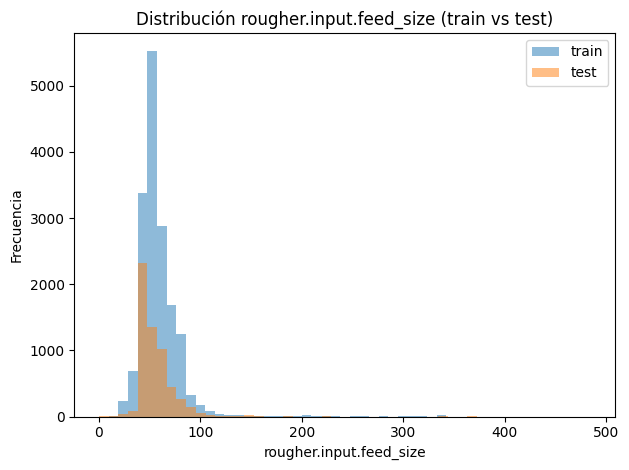

,col,KS_stat,p_value
1,rougher.input.feed_size,0.192311,5.871332e-140
0,primary_cleaner.input.feed_size,0.051982,1.202248e-10


In [6]:
size_cols = [c for c in COMMON_COLS if c.endswith('feed_size')]
print("Columnas feed_size encontradas:", len(size_cols))

for col in size_cols[:3]:  # máximo 3 plots
    plt.figure()
    plt.hist(X_train_raw[col].dropna(), bins=50, alpha=0.5, label='train')
    plt.hist(X_test_raw[col].dropna(),  bins=50, alpha=0.5, label='test')
    plt.title(f"Distribución {col} (train vs test)")
    plt.xlabel(col); plt.ylabel("Frecuencia"); plt.legend(); plt.tight_layout(); plt.show()

# KS test simple por cada feed_size (mide si hay cambio de distribución)
ks_rows = []
for col in size_cols:
    a = X_train_raw[col].dropna().values
    b = X_test_raw[col].dropna().values
    if len(a) > 0 and len(b) > 0:
        stat, p = ks_2samp(a, b)
        ks_rows.append({"col": col, "KS_stat": stat, "p_value": p})
ks_df = pd.DataFrame(ks_rows).sort_values("KS_stat", ascending=False)
display(ks_df.head(10))

**Comparación de feed_size entre train y test + prueba KS**

**Qué muestran los histogramas**

`primary_cleaner.input.feed_size`

Ambas distribuciones son unimodales y se solapan ampliamente.

test está ligeramente desplazado a la izquierda (tamaños algo menores) y tiene menor dispersión que train.

**Lectura:** hay desajuste leve entre conjuntos (pequeño covariate shift), pero con alto solapamiento.

`rougher.input.feed_size`

Distribución asimétrica a la derecha (cola larga).

train presenta una cola alta más marcada (más valores grandes y más variabilidad); test es más estrecho y algo más a la izquierda.

**Lectura:** aquí el covariate shift es mucho más claro; los tamaños en test se concentran más en rangos intermedios, mientras que train incluye más valores grandes (outliers).

**Prueba Kolmogorov–Smirnov (KS) — interpretación**

`primary_cleaner.input.feed_size`: KS_stat ≈ 0.052, p ≈ 1.20e-10

`rougher.input.feed_size`: KS_stat ≈ 0.192, p ≈ 5.87e-140

**Qué significan:**

KS_stat mide la diferencia máxima entre las CDF de train y test (0 = idénticas, 1 = totalmente distintas).

p_value muy pequeño ⇒ se rechaza la hipótesis nula de “misma distribución” con alta confianza.

Con tamaños muestrales grandes, p-values diminutos son frecuentes; por eso la magnitud la aporta KS_stat:

0.052 (pequeño) → diferencia leve en `primary_cleaner.input.feed_size`.

0.192 (moderada) → diferencia material en `rougher.input.feed_size`.

Con lo anterior, se podría proceder a entrenar los modelos y ver el rendimiento. En caso necesario, proceder a normailizar los datos.

## 6. EDA — Totales Au+Ag+Pb por etapa y limpieza de anomalías

,sum_feed,sum_rougher,sum_final
count,22716.000000,22716.000000,22716.000000
mean,18.833952,42.608343,67.847838
std,7.418530,15.457769,22.325105
min,0.000000,0.000000,0.000000
25%,16.447446,43.806424,72.236405
50%,19.560398,47.530613,75.086681
75%,23.572584,50.694841,77.473836
max,35.071987,74.348565,89.615564


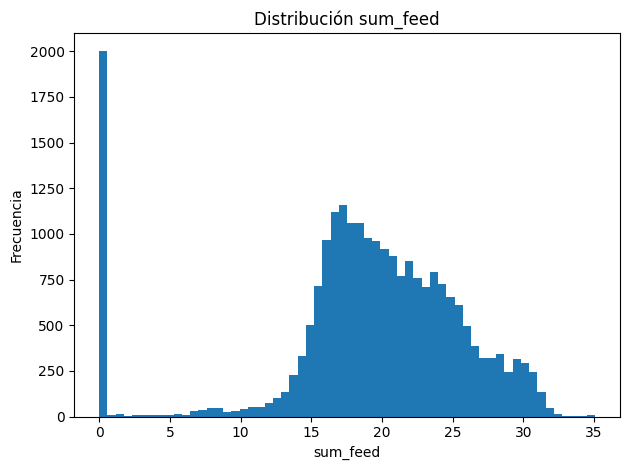

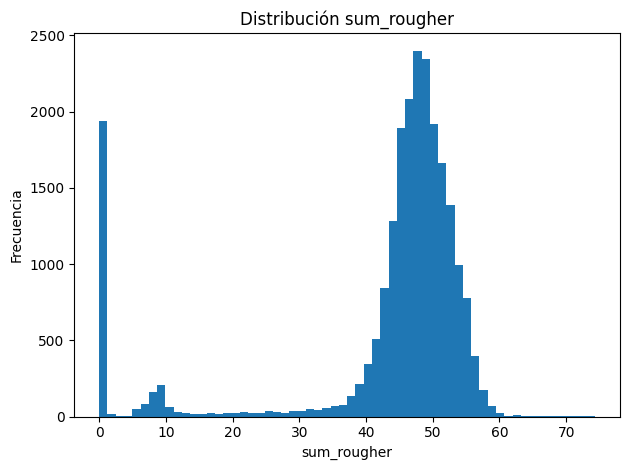

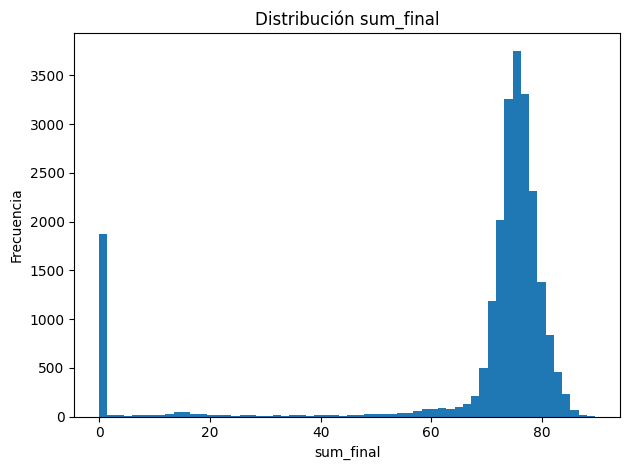

Filas anómalas (full): 1772
Tamaño train tras limpieza: (15502, 52)


In [7]:
def total_metals_sum(df, stage_token):
    cols = [c for c in df.columns if stage_token in c and (c.endswith('_au') or c.endswith('_ag') or c.endswith('_pb'))]
    if not cols: return pd.Series(index=df.index, dtype=float)
    return df[cols].sum(axis=1)


sum_feed    = total_metals_sum(df_full, 'rougher.input')
sum_rougher = total_metals_sum(df_full, 'rougher.output')
sum_final   = total_metals_sum(df_full, 'final.output')

totals = pd.DataFrame({'sum_feed':sum_feed,'sum_rougher':sum_rougher,'sum_final':sum_final})
display(totals.describe())

for c in totals.columns:
  plt.figure(); plt.hist(totals[c].dropna(), bins=60)
  plt.title(f"Distribución {c}"); plt.xlabel(c); plt.ylabel("Frecuencia")
  plt.tight_layout(); plt.show()

# Regla simple para anómalos
tiny = totals.quantile(0.001).min()
mask_anom = (totals <= 0).any(axis=1) | (totals <= tiny).any(axis=1)
print("Filas anómalas (full):", int(mask_anom.sum()))

# Indices anómalos en train/test
anom_train_idx = df_train.index.intersection(totals.index[mask_anom])
anom_test_idx  = df_test.index.intersection(totals.index[mask_anom])

# Por prudencia: limpiamos SOLO train (para no perder filas de predicción en test).
X_train_raw = X_train_raw.loc[~X_train_raw.index.isin(anom_train_idx)]
y_train_raw = y_train_raw.loc[~y_train_raw.index.isin(anom_train_idx)]

print("Tamaño train tras limpieza:", X_train_raw.shape)

**Interpretación**

**1) sum_feed (materia prima)**

**Forma:** unimodal con cola derecha (pico ~16–22) y palo enorme en 0.

**Interpretación:** el feed trae variabilidad real de composición (normal), pero ese pico en 0 es anómalo (sensores caídos, lecturas vacías o errores de ingestión). Físicamente, Au+Ag+Pb ≈ 0 no es razonable de forma masiva. Se procedió a eliminar esos datos anímalos en el conjunto de entrenamiento.

**2) sum_rougher (salida del rougher)**

**Forma:** distribución más estrecha y desplazada a la derecha (~45–55), con otro palo en 0 y un “hombro” bajo (~5–15).

**Interpretación:** el enriquecimiento post-rougher se nota (más metales totales en la corriente de concentrado rougher que en el feed), lo cual cuadra con la física del proceso. El palo en 0 y el hombro bajo son registros defectuosos o periodos atípicos (paro, dilución extrema, etiqueta equivocada).

**Implicación:** buen signo de proceso (concentración sube), pero hay outliers operativos que también se depuraron.

**3) sum_final (concentrado final)**

**Forma:** muy concentrada en ~70–80 con cola corta y otro palo en 0.

**Interpretación:** el sistema sí concentra metales de forma consistente hacia el final (perfil mucho más alto y estable). Los 0 siguen siendo no creíbles para esta etapa.

**Implicación:** la calidad del concentrado final es estable; los 0 se eliminaron para evitar sesgos.

# 3. Construcción del modelo

## 7. Métrica — sMAPE y sMAPE_final

In [8]:
# --- sMAPE por serie (maneja ceros/NaNs de forma robusta) ---
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    # Evitar división por cero: si denom=0 y también |y_true - y_pred|=0, ese término aporta 0
    with np.errstate(divide="ignore", invalid="ignore"):
        frac = np.where(denom == 0, 0.0, np.abs(y_pred - y_true) / denom)
    return float(np.mean(frac) * 100.0)

# --- sMAPE_final = 0.25*sMAPE(rougher) + 0.75*sMAPE(final) ---
def smape_final(y_true_df, y_pred_df):
    # y_*_df con columnas en orden TARGETS = ['rougher.output.recovery','final.output.recovery']
    r_col, f_col = TARGETS
    s_r = smape(y_true_df[r_col], y_pred_df[r_col])
    s_f = smape(y_true_df[f_col], y_pred_df[f_col])
    return 0.25 * s_r + 0.75 * s_f

## 8. Preprocesamiento — imputación y selección final

In [9]:
# === Saneo global: alinear y eliminar NaN en y (ambos targets) ===
r_col, f_col = TARGETS  # ['rougher.output.recovery','final.output.recovery']

# Mantener solo filas donde AMBOS targets estén presentes
valid_idx_y = y_train_raw[[r_col, f_col]].dropna().index

# Alinear X/Y al mismo índice válido
X_train_raw = X_train_raw.loc[valid_idx_y].copy()
y_train_raw = y_train_raw.loc[valid_idx_y].copy()

print("Post-saneo -> X_train_raw:", X_train_raw.shape, "| y_train_raw:", y_train_raw.shape)


Post-saneo -> X_train_raw: (14149, 52) | y_train_raw: (14149, 2)


In [10]:
RANDOM_STATE = 42

# Imputación común
imputer = SimpleImputer(strategy="median")

# Modelos base (para cada target entrenaremos por separado con clone)
pipelines = {
    "LinearRegression": Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "DecisionTreeRegressor": Pipeline([
        ("imputer", imputer),
        ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
    ]),
    "RandomForestRegressor": Pipeline([
        ("imputer", imputer),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
}


## 9. Modelado — TimeSeriesSplit CV (5 folds) y comparación de modelos


In [11]:
def evaluate_with_tss(X, y_df, pipe, n_splits=5):
    """
    Entrena 2 modelos (uno por target) por fold temporal.
    Hace saneo por target en cada fold (drop de NaN en y) para evitar ValueError.
    Retorna lista con sMAPE_final por fold y resumen.
    """
    tss = TimeSeriesSplit(n_splits=n_splits)
    scores = []

    r_col, f_col = TARGETS

    for fold, (tr_idx, va_idx) in enumerate(tss.split(X), start=1):
        X_tr_full, X_va_full = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr_full, y_va_full = y_df.iloc[tr_idx], y_df.iloc[va_idx]

        # --- Modelo para rougher ---
        pipe_r = clone(pipe)
        mask_tr_r = y_tr_full[r_col].notna()
        X_tr_r = X_tr_full.loc[mask_tr_r]
        y_tr_r = y_tr_full.loc[mask_tr_r, r_col]
        pipe_r.fit(X_tr_r, y_tr_r)

        # --- Modelo para final ---
        pipe_f = clone(pipe)
        mask_tr_f = y_tr_full[f_col].notna()
        X_tr_f = X_tr_full.loc[mask_tr_f]
        y_tr_f = y_tr_full.loc[mask_tr_f, f_col]
        pipe_f.fit(X_tr_f, y_tr_f)

        # Predicciones en validación (mismo índice de y_va_full)
        y_pred_va = pd.DataFrame(index=y_va_full.index, columns=TARGETS, dtype=float)
        y_pred_va[r_col] = pipe_r.predict(X_va_full)
        y_pred_va[f_col] = pipe_f.predict(X_va_full)

        # sMAPE_final (tu función ya ignora NaN con máscara interna)
        score_fold = smape_final(y_va_full[TARGETS], y_pred_va[TARGETS])
        scores.append(score_fold)
        print(f"[Fold {fold}] sMAPE_final: {score_fold:.3f}%")

    summary = {
        "cv_mean": float(np.mean(scores)),
        "cv_std" : float(np.std(scores)),
        "cv_all" : scores
    }
    print(f"CV sMAPE_final -> mean: {summary['cv_mean']:.3f}% | std: {summary['cv_std']:.3f}%")
    return scores, summary


## 10. Selección del mejor modelo

In [12]:
# === Comparativa de modelos por validación temporal y selección del mejor ===

cv_results = []

for name, pipe in pipelines.items():
    print(f"\n=== {name} ===")
    _, summ = evaluate_with_tss(
        X_train_raw,
        y_train_raw[TARGETS],
        pipe,
        n_splits=5
    )
    cv_results.append({
        "model": name,
        "cv_mean_sMAPE_final": summ["cv_mean"],
        "cv_std": summ["cv_std"]
    })

cv_df = pd.DataFrame(cv_results).sort_values("cv_mean_sMAPE_final", ascending=True)

print("\nRanking por CV (menor sMAPE_final es mejor):")
print(cv_df.to_string(index=False, float_format=lambda x: f"{x:.3f}%"))

# Seleccionar el mejor por media de sMAPE_final
best_row = cv_df.iloc[0]
BEST_MODEL_NAME = str(best_row["model"])

print(f"\n➡️ Mejor modelo por CV: {BEST_MODEL_NAME} "
      f"(sMAPE_final mean={best_row['cv_mean_sMAPE_final']:.3f}%, "
      f"std={best_row['cv_std']:.3f}%)")



=== LinearRegression ===
[Fold 1] sMAPE_final: 15.253%
[Fold 2] sMAPE_final: 11.793%
[Fold 3] sMAPE_final: 15.284%
[Fold 4] sMAPE_final: 16.474%
[Fold 5] sMAPE_final: 13.927%
CV sMAPE_final -> mean: 14.546% | std: 1.595%

=== DecisionTreeRegressor ===
[Fold 1] sMAPE_final: 19.072%
[Fold 2] sMAPE_final: 25.513%
[Fold 3] sMAPE_final: 31.171%
[Fold 4] sMAPE_final: 17.100%
[Fold 5] sMAPE_final: 20.414%
CV sMAPE_final -> mean: 22.654% | std: 5.087%

=== RandomForestRegressor ===
[Fold 1] sMAPE_final: 15.543%
[Fold 2] sMAPE_final: 15.782%
[Fold 3] sMAPE_final: 15.045%
[Fold 4] sMAPE_final: 14.466%
[Fold 5] sMAPE_final: 11.248%
CV sMAPE_final -> mean: 14.417% | std: 1.647%

Ranking por CV (menor sMAPE_final es mejor):
                model  cv_mean_sMAPE_final  cv_std
RandomForestRegressor              14.417%  1.647%
     LinearRegression              14.546%  1.595%
DecisionTreeRegressor              22.654%  5.087%

➡️ Mejor modelo por CV: RandomForestRegressor (sMAPE_final mean=14.417%, 

## 10. Entrenamiento final del mejor modelo y predicción en test

In [13]:
BEST_PIPE_BASE = pipelines[BEST_MODEL_NAME]

# y_test desde df_full para los índices de X_test_raw
y_test_full = df_full.loc[X_test_raw.index, TARGETS].copy()
valid_idx = y_test_full.dropna().index
X_test_eval = X_test_raw.loc[valid_idx]
y_test_eval = y_test_full.loc[valid_idx]

# Reentrenar con todo el train saneado
r_col, f_col = TARGETS
pipe_r_full = clone(BEST_PIPE_BASE).fit(X_train_raw, y_train_raw[r_col])
pipe_f_full = clone(BEST_PIPE_BASE).fit(X_train_raw, y_train_raw[f_col])

# Predicción y métricas
y_pred_test = pd.DataFrame(index=y_test_eval.index, columns=TARGETS, dtype=float)
y_pred_test[r_col] = pipe_r_full.predict(X_test_eval)
y_pred_test[f_col] = pipe_f_full.predict(X_test_eval)

smape_r = smape(y_test_eval[r_col], y_pred_test[r_col])
smape_f = smape(y_test_eval[f_col], y_pred_test[f_col])
smape_fin = smape_final(y_test_eval[TARGETS], y_pred_test[TARGETS])

print(f"\n=== Resultados en TEST ===")
print(f"sMAPE(rougher): {smape_r:.3f}%")
print(f"sMAPE(final)  : {smape_f:.3f}%")
print(f"sMAPE_final   : {smape_fin:.3f}%")

preds_entregables = y_pred_test.copy()
preds_entregables.columns = [c + "_pred" for c in preds_entregables.columns]
display(preds_entregables.head())



=== Resultados en TEST ===
sMAPE(rougher): 13.359%
sMAPE(final)  : 10.214%
sMAPE_final   : 11.000%


,rougher.output.recovery_pred,final.output.recovery_pred
date,,
2016-09-01 00:59:59,87.760892,68.508555
2016-09-01 01:59:59,87.349908,69.084497
2016-09-01 02:59:59,85.447651,69.126504
2016-09-01 03:59:59,86.371637,69.714992
2016-09-01 04:59:59,87.948019,68.849352


## 11. Resumen de insights

In [14]:
# === Construcción de resumen de insights ===

# Guardar predicciones entregables a CSV
PRED_CSV_PATH = "predicciones_test.csv"
preds_entregables.to_csv(PRED_CSV_PATH)

# Crear un dict de métricas CV por modelo
cv_means = dict(zip(cv_df["model"], cv_df["cv_mean_sMAPE_final"]))
cv_stds  = dict(zip(cv_df["model"], cv_df["cv_std"]))

summary = {
    "MAE verificación fórmula (rougher)": float(mae_check),
    "Nº columnas ausentes en test": int(len(missing_in_test)),
    "Nº features usadas (intersección)": int(len(COMMON_COLS)),
    "Rows de train tras limpieza": int(X_train_raw.shape[0]),

    "Mejor modelo (CV)": BEST_MODEL_NAME,
    "sMAPE_final CV (LinearRegression)": float(cv_means.get("LinearRegression", float("nan"))),
    "sMAPE_final CV (DecisionTreeRegressor)": float(cv_means.get("DecisionTreeRegressor", float("nan"))),
    "sMAPE_final CV (RandomForestRegressor)": float(cv_means.get("RandomForestRegressor", float("nan"))),

    "sMAPE(rougher) TEST": float(smape_r),
    "sMAPE(final)  TEST": float(smape_f),
    "sMAPE_final   TEST": float(smape_fin),

    "Archivo de predicciones test": PRED_CSV_PATH
}
summary


{'MAE verificación fórmula (rougher)': 9.303415616264301e-15,
 'Nº columnas ausentes en test': 34,
 'Nº features usadas (intersección)': 52,
 'Rows de train tras limpieza': 14149,
 'Mejor modelo (CV)': 'RandomForestRegressor',
 'sMAPE_final CV (LinearRegression)': 14.546337277065854,
 'sMAPE_final CV (DecisionTreeRegressor)': 22.65382914060976,
 'sMAPE_final CV (RandomForestRegressor)': 14.416872518696982,
 'sMAPE(rougher) TEST': 13.358721511741628,
 'sMAPE(final)  TEST': 10.213739111433235,
 'sMAPE_final   TEST': 10.999984711510333,
 'Archivo de predicciones test': 'predicciones_test.csv'}